# Tinder for RL 
## RLI 22.00 · Group Assignment · IE University BCSAI · 2026

### Part 01

---

## Introduction

The MountainCar problem presented in this RL assignment is interesting because:
It's simple enough to be solved, yet it's difficult enough to show the fundamental differences between learning algorithms. MountainCar involves an under-powered car in a valley attempting to reach a flag on the top of the right hand hill. The car is too weak to drive directly up, gravity pulls it down to the valley. 

The only possible way is to learn how to build up momentum through trial and error by oscillating to the left and right until there's enough potential energy to reach the goal, an unexpected solution.


Our study is organized around four scenarios that cross two axes: **action space type** (discrete vs. continuous) and **reward/cost formulation** (minimize steps vs. minimize fuel). Within each scenario we compare two algorithms suited to that action space. Across scenarios with the same action space, we hold the algorithms fixed and vary only the reward, isolating the effect of reward engineering on the learned policy.

For the **discrete scenarios**, we compare **Q-Learning** against **DQN**. Q-Learning discretizes the state space into bins and builds an explicit lookup table, giving us a fully interpretable policy, every state's preferred action can be read directly from the table and visualized as a phase portrait. DQN replaces that table with a neural network, operating on the raw continuous state without discretization loss. The comparison directly answers whether function approximation adds value on a problem this small, or whether the tabular method is already sufficient.

For the **continuous scenarios**, tabular methods are infeasible. We compare **TD3** and **SAC**, both actor-critic algorithms that learn a policy network alongside a value estimator. TD3 is deterministic: it outputs a single action per state and stabilizes training through twin critics and delayed updates. SAC is stochastic: it maximizes a entropy-augmented objective, explicitly rewarding the agent for maintaining an exploratory, spread-out policy. This entropy regularization is particularly relevant here: in scenarios where large actions are penalized, SAC's natural tendency toward low-magnitude, high-entropy behavior aligns directly with the cost structure of the problem.

The four scenarios together enable both algorithm benchmarking and a principled analysis of how reward shaping alters policy structure (which is, ultimately, what this assignment is about).






---



## Scenario 1 — Discrete MountainCar: Minimum Steps

**Environment**: `MountainCar-v0` · **Objective**: Reach the goal in as few timesteps as possible

---

The first scenario uses the discrete version of MountainCar with its default reward structure: the agent receives **−1 for every timestep** until it reaches the flag. The default environment provides no partial credit or progress signal (just a constant −1 penalty per timestep), so both algorithms add a +100 goal bonus during training to enable discovery, while evaluation uses the unmodified reward to measure true performance.

This makes the problem deceptively hard: 

the agent must stumble upon the goal through exploration before it can learn anything meaningful, and early in training almost every episode simply truncates at 200 steps.

The action space has three choices at each step: push left (0), do nothing (1), or push right (2). The optimal policy is not "always push right", the car would lack the torque to climb directly. It must learn to rock back and forth, building kinetic energy through momentum before committing to the final climb. This emergent behavior is what makes Scenario 1 a clean test of whether an algorithm can discover a multi-step, physically-grounded strategy from a sparse, undifferentiated reward signal.


### Algorithms

**Q-Learning** discretizes the continuous state space into a **40×40 grid** (position × velocity), yielding 1,600 discrete states. Each cell maps to a Q-value for each of the 3 actions, updated via the Bellman equation with a learning rate of **α = 0.1**, small enough for stable updates, large enough to learn within 25,000 episodes. The discount factor **γ = 0.99** keeps future rewards nearly as valuable as immediate ones, which matters here because the goal can only be reached many steps into the future. Exploration follows ε-greedy decay from **1.0 → 0.02** at a rate of **0.9997 per episode**, giving the agent a long exploratory phase before committing to a policy. Because the default −1/step signal is too sparse for tabular bootstrapping to work reliably, we add a **+100 goal bonus** on termination, this preserves the optimal policy ordering while giving the Q-table a concrete value to propagate backwards from. All randomness is seeded at **seed = 42**, applied to both `np.random` and the environment reset.

**DQN** uses the **same +100 goal bonus**, applied via a `ShapedMountainCar` gym wrapper that intercepts the reward on termination before it reaches the replay buffer. This is a deliberate design choice: by keeping the reward structure identical across both algorithms, any performance difference in Scenario 1 is attributable to the algorithm itself (tabular vs. function approximation)  rather than to asymmetric learning signals. The network is a **two-layer MLP [128, 128]** mapping the raw continuous state directly to Q-values. Learning rate is **5e-4**, with a **replay buffer of 50,000 transitions** and a **1,000-step warmup** before any gradient updates. Batches of **64 transitions** are sampled every **4 environment steps**, and the target network hard-updates every **1,000 steps**. Exploration decays from **1.0 → 0.02** over **35% of total timesteps**. Trained for **200,000 environment steps** at **seed = 42**.

Both algorithms are evaluated on the **unmodified −1/step reward**, the shaping is training-only. This separates the engineered learning signal from the true objective performance, making the evaluation metrics directly comparable across scenarios.

In [1]:
import json
import numpy as np
from pathlib import Path

# Notebook is in root, results are in training/results/
METRICS_DIR = Path("training/results/scenario1/metrics")

# Check if path exists, if not try alternate location
if not METRICS_DIR.exists():
    METRICS_DIR = Path("results/scenario1/metrics")
    if not METRICS_DIR.exists():
        print("❌ Error: Results not found!")
        print("Make sure you've run the training scripts first:")
        print("  python training/scenario1_qlearning.py")
        print("  python training/scenario1_dqn.py")
        raise FileNotFoundError(f"No results found at {METRICS_DIR}")

with open(METRICS_DIR / "scenario1_qtable.json") as f:
    qtable_metrics = json.load(f)

with open(METRICS_DIR / "scenario1_dqn.json") as f:
    dqn_metrics = json.load(f)

metrics_to_show = [
    ("Success Rate (%)",     "success_rate_percent"),
    ("Avg Reward",           "average_reward"),
    ("Avg Steps",            "average_steps"),
    ("Avg Fuel",             "average_fuel"),
    ("Min Steps",            "min_steps"),
    ("Max Steps",            "max_steps"),
    ("Training Time (s)",    "training_time_seconds"),
]

print("=" * 57)
print("SCENARIO 1: Discrete MountainCar - Minimum Steps")
print("=" * 57)
print(f"{'Metric':<25} {'Q-Learning':>15} {'DQN':>15}")
print("-" * 57)
for label, key in metrics_to_show:
    q_val = qtable_metrics.get(key, "N/A")
    d_val = dqn_metrics.get(key, "N/A")
    if isinstance(q_val, float):
        print(f"{label:<25} {q_val:>15.2f} {d_val:>15.2f}")
    else:
        print(f"{label:<25} {str(q_val):>15} {str(d_val):>15}")
print("=" * 57)

SCENARIO 1: Discrete MountainCar - Minimum Steps
Metric                         Q-Learning             DQN
---------------------------------------------------------
Success Rate (%)                   100.00           81.00
Avg Reward                        -125.31         -160.05
Avg Steps                          125.31          160.05
Avg Fuel                           107.71          156.42
Min Steps                              95              97
Max Steps                             158             200
Training Time (s)                   72.85           33.63


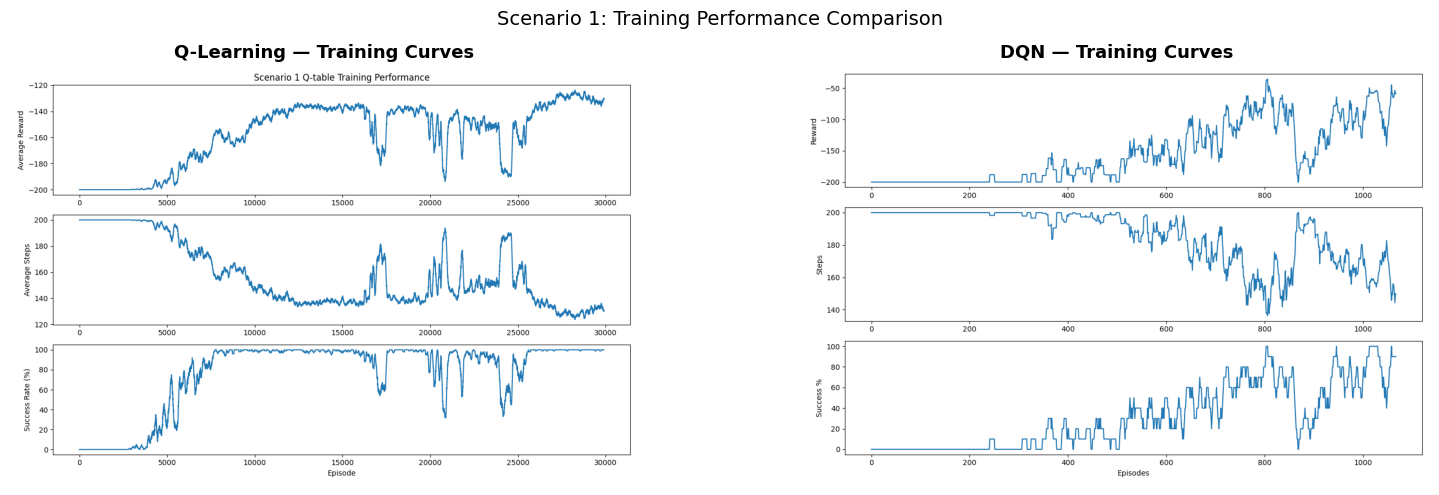

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

# Update to use correct path
SCENARIO1_DIR = Path("training/results/scenario1")

# Check if path exists, if not try alternate
if not SCENARIO1_DIR.exists():
    SCENARIO1_DIR = Path("results/scenario1")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

qtable_img = mpimg.imread(SCENARIO1_DIR / "plots/scenario1_qtable_training.png")
dqn_img    = mpimg.imread(SCENARIO1_DIR / "plots/scenario1_dqn_training.png")

axes[0].imshow(qtable_img)
axes[0].axis("off")
axes[0].set_title("Q-Learning — Training Curves", fontsize=13, fontweight="bold")

axes[1].imshow(dqn_img)
axes[1].axis("off")
axes[1].set_title("DQN — Training Curves", fontsize=13, fontweight="bold")

plt.suptitle("Scenario 1: Training Performance Comparison", fontsize=14)
plt.tight_layout()
plt.show()

## Scenario 1 — Discrete MountainCar: Minimum Steps

This scenario uses `MountainCar-v0`, where the agent has three discrete actions: push left, do nothing, or push right. The objective is to reach the goal in as few timesteps as possible.

We compare two algorithms:

- **Q-learning with a Q-table**
- **DQN**

Both algorithms are trained with the same terminal reward shaping: a `+100` bonus when the goal is reached. Evaluation is done using the normal environment reward, so the final metrics reflect true task performance.

This section follows the assignment requirement to evaluate, compare, and interpret the learned policies, including numerical performance and policy visualizations. 

In [3]:
import json
import pickle
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from stable_baselines3 import DQN

### 1. Load Scenario 1 Results

The metrics are loaded from the JSON files generated by the training scripts. These include success rate, average reward, average number of steps, fuel usage, and training time.

In [4]:
def load_json(path):
    with open(path, "r") as file:
        return json.load(file)

qtable_metrics = load_json(METRICS_DIR / "scenario1_qtable.json")
dqn_metrics = load_json(METRICS_DIR / "scenario1_dqn.json")

qtable_metrics, dqn_metrics

({'scenario': 1,
  'algorithm': 'Q-table',
  'environment': 'MountainCar-v0',
  'objective': 'minimum_steps',
  'training_episodes': 30000,
  'evaluation_episodes': 100,
  'seed': 42,
  'success_rate': 1.0,
  'success_rate_percent': 100.0,
  'average_reward': -125.31,
  'average_steps': 125.31,
  'average_fuel': 107.71,
  'min_steps': 95,
  'max_steps': 158,
  'training_time_seconds': 72.84929299354553},
 {'scenario': 1,
  'algorithm': 'DQN',
  'environment': 'MountainCar-v0',
  'objective': 'minimum_steps',
  'total_timesteps': 200000,
  'evaluation_episodes': 100,
  'seed': 42,
  'success_rate': 0.81,
  'success_rate_percent': 81.0,
  'average_reward': -160.05,
  'average_steps': 160.05,
  'average_fuel': 156.42,
  'min_steps': 97,
  'max_steps': 200,
  'training_time_seconds': 33.63407301902771})

In [5]:
comparison_df = pd.DataFrame([
    {
        "Algorithm": "Q-learning",
        "Success Rate (%)": qtable_metrics["success_rate_percent"],
        "Average Reward": qtable_metrics["average_reward"],
        "Average Steps": qtable_metrics["average_steps"],
        "Average Fuel": qtable_metrics["average_fuel"],
        "Min Steps": qtable_metrics["min_steps"],
        "Max Steps": qtable_metrics["max_steps"],
        "Training Time (s)": qtable_metrics["training_time_seconds"],
    },
    {
        "Algorithm": "DQN",
        "Success Rate (%)": dqn_metrics["success_rate_percent"],
        "Average Reward": dqn_metrics["average_reward"],
        "Average Steps": dqn_metrics["average_steps"],
        "Average Fuel": dqn_metrics["average_fuel"],
        "Min Steps": dqn_metrics["min_steps"],
        "Max Steps": dqn_metrics["max_steps"],
        "Training Time (s)": dqn_metrics["training_time_seconds"],
    }
])

comparison_df

,Algorithm,Success Rate (%),Average Reward,Average Steps,Average Fuel,Min Steps,Max Steps,Training Time (s)
0,Q-learning,100.0,-125.31,125.31,107.71,95,158,72.849293
1,DQN,81.0,-160.05,160.05,156.42,97,200,33.634073


### 2. Numerical Results Interpretation

The main metric for Scenario 1 is **average steps**, because the objective is to reach the goal as quickly as possible. Success rate is also important because a faster policy is only meaningful if the agent actually reaches the goal.

Q-learning is expected to perform strongly here because the state space is small enough to discretize. DQN is more flexible, but it must approximate the Q-function with a neural network, which can make training less stable in small environments.

Using: results\plots


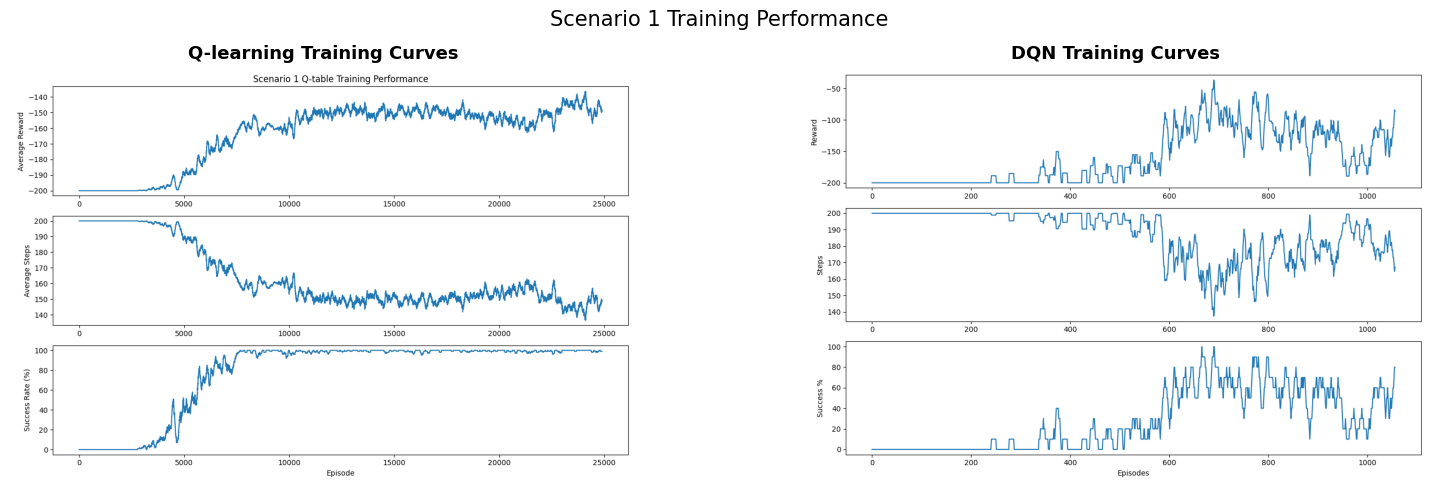

In [6]:
from pathlib import Path
import matplotlib.image as mpimg

possible_roots = [
    Path("results"),
    Path("training/results"),
    Path("../results"),
]

RESULTS_DIR = None

for path in possible_roots:
    if path.exists():
        RESULTS_DIR = path
        break

if RESULTS_DIR is None:
    raise FileNotFoundError("Could not find results folder.")

PLOTS_DIR = RESULTS_DIR / "plots"

print("Using:", PLOTS_DIR)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

qtable_plot = mpimg.imread(PLOTS_DIR / "scenario1_qtable_training.png")
dqn_plot = mpimg.imread(PLOTS_DIR / "scenario1_dqn_training.png")

axes[0].imshow(qtable_plot)
axes[0].axis("off")
axes[0].set_title("Q-learning Training Curves", fontsize=13, fontweight="bold")

axes[1].imshow(dqn_plot)
axes[1].axis("off")
axes[1].set_title("DQN Training Curves", fontsize=13, fontweight="bold")

plt.suptitle("Scenario 1 Training Performance", fontsize=15)
plt.tight_layout()
plt.show()

### 3. Q-table Policy Visualization

The Q-table allows direct interpretation because each discretized state stores one Q-value for each action. By taking the action with the highest Q-value, we can visualize the learned policy across the position-velocity space.

The colors represent:

- `0` = push left
- `1` = do nothing
- `2` = push right

In [7]:
from pathlib import Path

possible_roots = [
    Path("results"),
    Path("training/results"),
    Path("../results"),
]

RESULTS_DIR = None

for path in possible_roots:
    if path.exists():
        RESULTS_DIR = path
        break

if RESULTS_DIR is None:
    raise FileNotFoundError("Could not find results folder.")

METRICS_DIR = RESULTS_DIR / "metrics"
MODELS_DIR = RESULTS_DIR / "models"
PLOTS_DIR   = RESULTS_DIR / "plots"

print("RESULTS_DIR:", RESULTS_DIR)
print("MODELS_DIR:", MODELS_DIR)

with open(MODELS_DIR / "scenario1_qtable.pkl", "rb") as file:
    qtable_data = pickle.load(file)

q_table = qtable_data["q_table"]
position_bins = qtable_data["position_bins"]
velocity_bins = qtable_data["velocity_bins"]

best_actions = np.argmax(q_table, axis=2)

print("Q-table shape:", q_table.shape)
print("Best action map shape:", best_actions.shape)

RESULTS_DIR: results
MODELS_DIR: results\models
Q-table shape: (40, 40, 3)
Best action map shape: (40, 40)


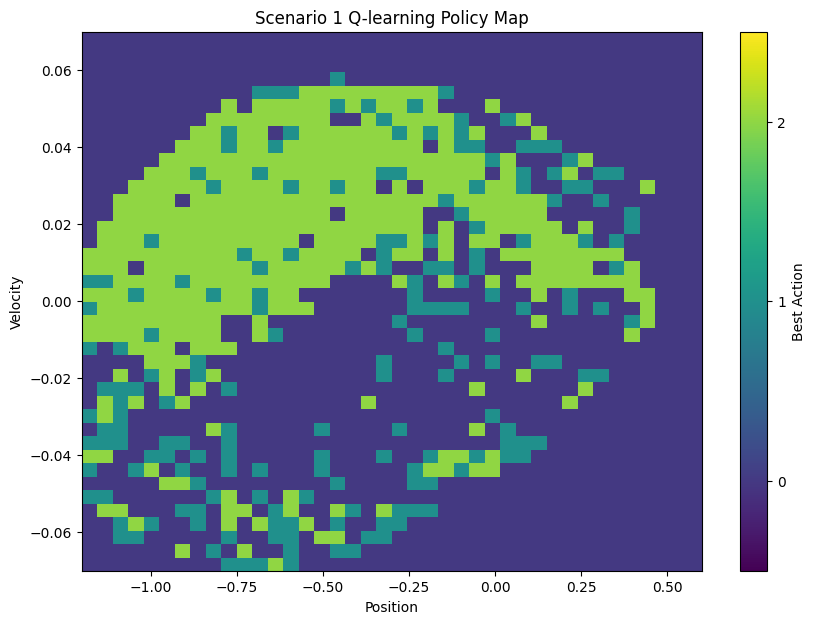

In [8]:
plt.figure(figsize=(10, 7))

plt.imshow(
    best_actions.T,
    origin="lower",
    aspect="auto",
    extent=[
        position_bins[0],
        position_bins[-1],
        velocity_bins[0],
        velocity_bins[-1]
    ]
)

plt.colorbar(ticks=[0, 1, 2], label="Best Action")
plt.clim(-0.5, 2.5)

plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 1 Q-learning Policy Map")

plt.show()

### 4. Q-table Value Function Visualization

The value of a state can be approximated by taking the maximum Q-value across all actions. This tells us how valuable the agent believes each state is.

States closer to successful trajectories should generally have higher values because they are more likely to lead to the goal.

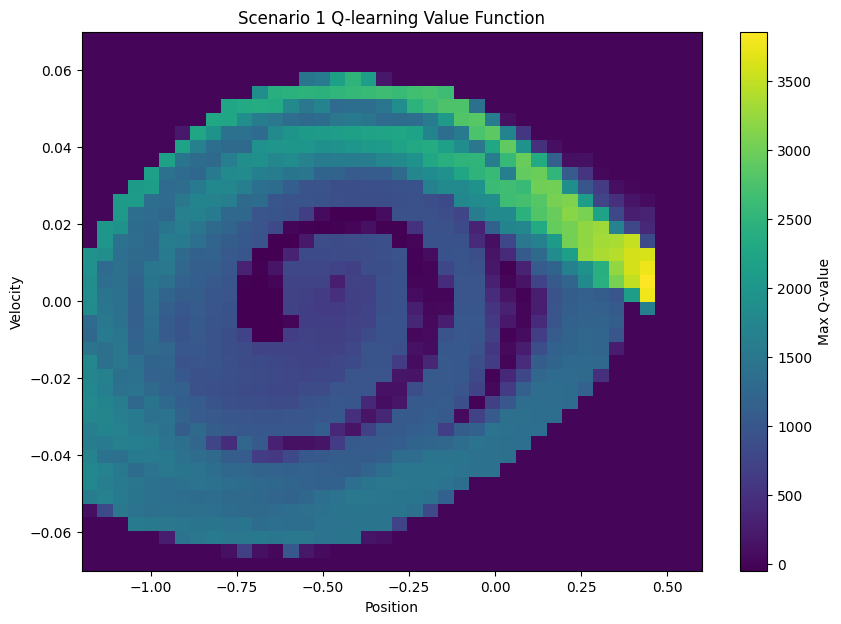

In [9]:
state_values = np.max(q_table, axis=2)

plt.figure(figsize=(10, 7))

plt.imshow(
    state_values.T,
    origin="lower",
    aspect="auto",
    extent=[
        position_bins[0],
        position_bins[-1],
        velocity_bins[0],
        velocity_bins[-1]
    ]
)

plt.colorbar(label="Max Q-value")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 1 Q-learning Value Function")

plt.show()

### 4.1 Q-values per Action (3D Visualization)

While the value function shows the maximum value across actions, we can also inspect the Q-values for each action individually.

These surfaces show how the agent evaluates each action at every state. This gives deeper insight into how the policy is formed, since the final decision is based on comparing these values.

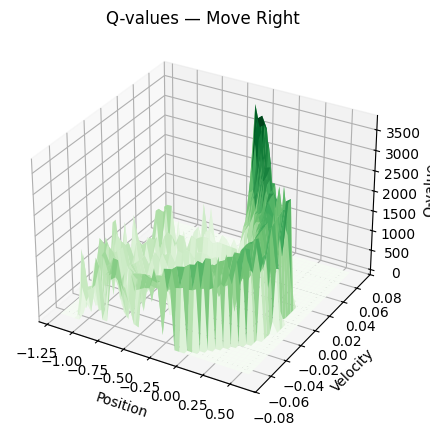

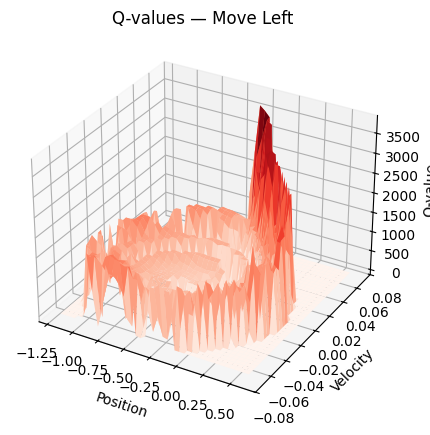

In [15]:
from mpl_toolkits.mplot3d import Axes3D

def plot_surface(Z, title, cmap):
    fig = plt.figure(figsize=(7,5))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(X, Y, Z, cmap=cmap)

    ax.set_xlabel("Position")
    ax.set_ylabel("Velocity")
    ax.set_zlabel("Q-value")
    ax.set_title(title)

    plt.show()


# Create grid (use bins you already loaded)
X, Y = np.meshgrid(position_bins, velocity_bins)

Z_left  = q_table[:, :, 0]
Z_none  = q_table[:, :, 1]
Z_right = q_table[:, :, 2]

plot_surface(Z_right, "Q-values — Move Right", "Greens")
plot_surface(Z_left,  "Q-values — Move Left",  "Reds")

### 5. Trajectory / Phase Portrait

A phase portrait plots position against velocity over time. This helps us understand the physical behavior of the learned policy.

For MountainCar, a successful policy should not go directly right. Instead, the car should move back and forth through the valley to build momentum before climbing the right hill.

In [10]:
def discretize_state(state, position_bins, velocity_bins):
    position = state[0]
    velocity = state[1]

    position_index = np.digitize(position, position_bins) - 1
    velocity_index = np.digitize(velocity, velocity_bins) - 1

    position_index = np.clip(position_index, 0, len(position_bins) - 1)
    velocity_index = np.clip(velocity_index, 0, len(velocity_bins) - 1)

    return position_index, velocity_index


def run_qtable_episode(q_table, position_bins, velocity_bins, seed=None):
    env = gym.make("MountainCar-v0")

    state, _ = env.reset(seed=seed)

    positions = []
    velocities = []
    actions = []
    total_reward = 0

    for step in range(200):
        discrete_state = discretize_state(state, position_bins, velocity_bins)
        action = int(np.argmax(q_table[discrete_state]))

        positions.append(state[0])
        velocities.append(state[1])
        actions.append(action)

        state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward

        if terminated or truncated:
            break

    env.close()

    return {
        "positions": positions,
        "velocities": velocities,
        "actions": actions,
        "steps": len(positions),
        "reward": total_reward,
        "success": positions[-1] >= 0.5 if len(positions) > 0 else False
    }

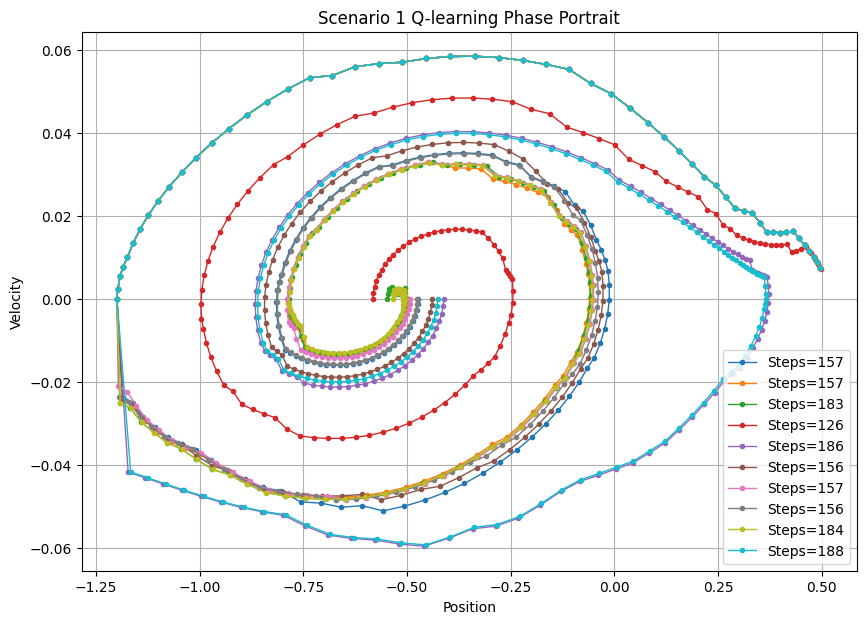

In [11]:
plt.figure(figsize=(10, 7))

for seed in range(10):
    episode = run_qtable_episode(q_table, position_bins, velocity_bins, seed=seed)
    plt.plot(
        episode["positions"],
        episode["velocities"],
        marker="o",
        markersize=3,
        linewidth=1,
        label=f"Steps={episode['steps']}"
    )

plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 1 Q-learning Phase Portrait")
plt.legend()
plt.grid(True)
plt.show()

### 6. State Visitation Map

This map shows which discretized states are visited during evaluation episodes. It is not the full training visitation history, but it still gives an estimate of where the learned policy spends time.

Frequently visited states are generally more reliable because the policy has more experience in those regions of the state space.

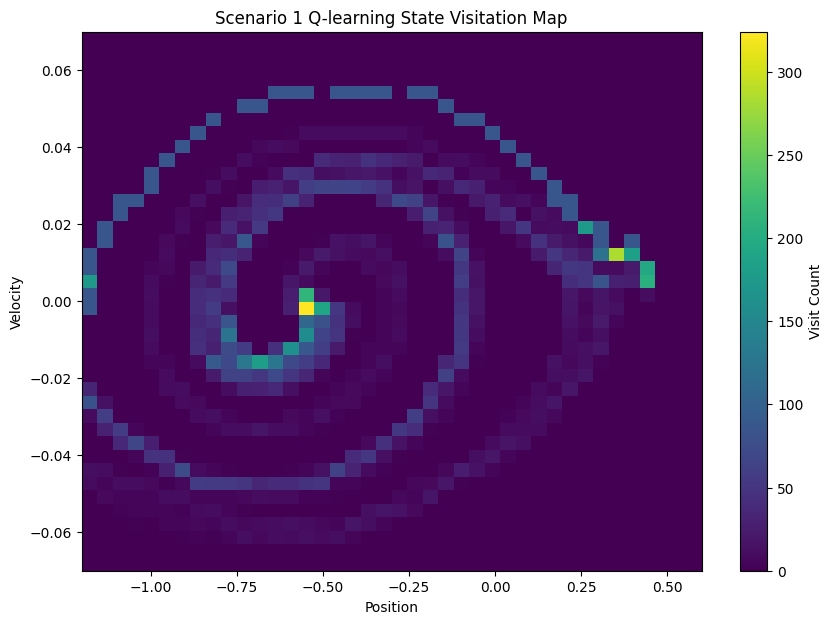

In [12]:
visit_counts = np.zeros((len(position_bins), len(velocity_bins)))

for seed in range(100):
    episode = run_qtable_episode(q_table, position_bins, velocity_bins, seed=seed)

    for position, velocity in zip(episode["positions"], episode["velocities"]):
        position_index = np.digitize(position, position_bins) - 1
        velocity_index = np.digitize(velocity, velocity_bins) - 1

        position_index = np.clip(position_index, 0, len(position_bins) - 1)
        velocity_index = np.clip(velocity_index, 0, len(velocity_bins) - 1)

        visit_counts[position_index, velocity_index] += 1

plt.figure(figsize=(10, 7))

plt.imshow(
    visit_counts.T,
    origin="lower",
    aspect="auto",
    extent=[
        position_bins[0],
        position_bins[-1],
        velocity_bins[0],
        velocity_bins[-1]
    ]
)

plt.colorbar(label="Visit Count")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 1 Q-learning State Visitation Map")

plt.show()

### 7. DQN Trajectory Analysis

Unlike Q-learning, DQN does not store an explicit table of values for each discretized state. Its policy is stored inside a neural network. Because of this, DQN is less directly interpretable.

However, we can still analyze its behavior by plotting the trajectories it produces during evaluation.

training\results\scenario1\models
[WindowsPath('training/results/scenario1/models/scenario1_dqn.zip')]


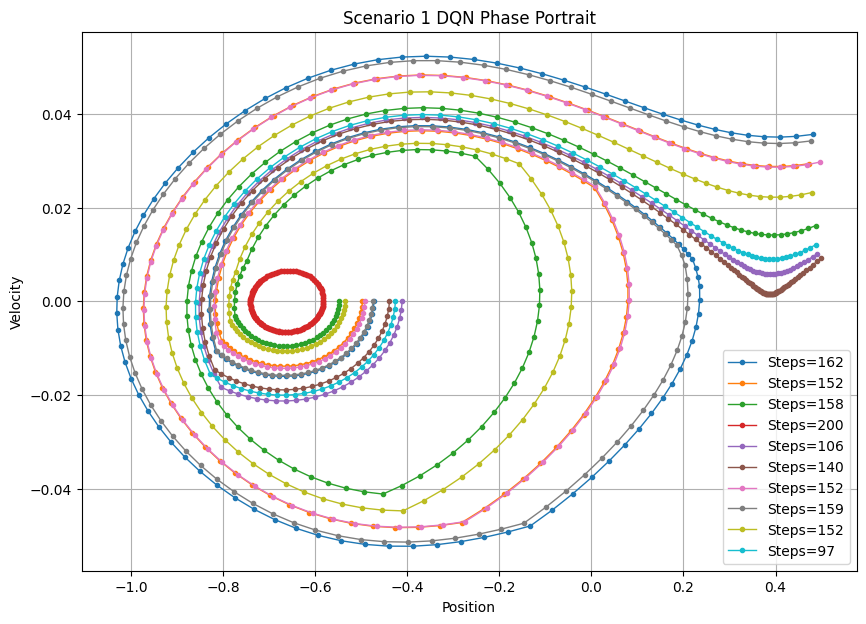

In [13]:
from pathlib import Path

BASE_DIR = Path("training/results")

METRICS_DIR = BASE_DIR / "scenario1" / "metrics"
MODELS_DIR  = BASE_DIR / "scenario1" / "models"
PLOTS_DIR   = BASE_DIR / "scenario1" / "plots"

print(MODELS_DIR)
print(list(MODELS_DIR.glob("scenario1_dqn*")))

dqn_model = DQN.load(MODELS_DIR / "scenario1_dqn")


def run_dqn_episode(model, seed=None):
    env = gym.make("MountainCar-v0")
    state, _ = env.reset(seed=seed)

    positions = []
    velocities = []
    actions = []
    total_reward = 0

    for step in range(200):
        action, _ = model.predict(state, deterministic=True)
        action = int(action)

        positions.append(state[0])
        velocities.append(state[1])
        actions.append(action)

        state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward

        if terminated or truncated:
            break

    env.close()

    return {
        "positions": positions,
        "velocities": velocities,
        "actions": actions,
        "steps": len(positions),
        "reward": total_reward,
        "success": positions[-1] >= 0.5 if len(positions) > 0 else False
    }


plt.figure(figsize=(10, 7))

for seed in range(10):
    episode = run_dqn_episode(dqn_model, seed=seed)
    plt.plot(
        episode["positions"],
        episode["velocities"],
        marker="o",
        markersize=3,
        linewidth=1,
        label=f"Steps={episode['steps']}"
    )

plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 1 DQN Phase Portrait")
plt.legend()
plt.grid(True)
plt.show()

### Scenario 1 Interpretation and Conclusion

Q-learning performed strongly in Scenario 1 because the state space is small enough to discretize effectively. With a 40×40 grid, the Q-table stores explicit values for 1,600 states and 3 actions per state. This makes the learned policy stable and interpretable.

The Q-table policy map shows that the agent does not simply push right at every state. Instead, it learns a momentum-building strategy: moving left in some regions to gain energy, then pushing right once enough velocity has been built. This matches the physics of the MountainCar environment.

The value map shows which states the agent considers more useful for reaching the goal, while the visitation map shows which parts of the state space are actually used by the learned policy. The phase portraits confirm the expected oscillating behavior: the car swings through the valley before climbing the right hill.

DQN also learns the task, but it is less interpretable because its policy is represented by neural network weights rather than an explicit table. In this small environment, the tabular method is highly competitive because it avoids function approximation error and directly stores action values for each discretized state.

Overall, Scenario 1 shows that deep reinforcement learning is not always automatically superior. For low-dimensional problems where the state space can be discretized effectively, tabular Q-learning can be simpler, more interpretable, and highly effective.